# 4 · Seed-ensemble: el modelo final

El VAE `recon_prob` era el mejor pero **cada semilla converge distinto** → varianza
alta. Solución: **seed-ensemble** — entrenar N VAEs con semillas distintas y **promediar
sus scores** (z-normalizados por miembro). El ruido idiosincrático se cancela.

In [47]:
import lab                      # utilidades: métricas y gráficos (experiments/lab.py)
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from src import config, data
from src.models import (IsolationForestDetector, OneClassSVMDetector,
                        ZScoreDetector, MahalanobisDetector,
                        AEDetector, DenoisingAEDetector, VAEDetector,
                        EnsembleDetector, DeepODDetector)
plt.rcParams["figure.dpi"] = 110
SEEDS = lab.SEEDS            # 10 semillas del estudio. Bajalas (p. ej. [42,43,44])
print("semillas:", SEEDS)   # para un Run all más rápido; los números se mueven ±std

semillas: [42, 43, 44, 45, 46, 47, 48, 49, 50, 51]


In [48]:
panel_z = data.prepare()                         # panel + etiqueta z_rinde
ds   = data.build_crop_dataset(panel_z, "soja")  # split + normalización (soja)
dsm  = data.build_crop_dataset(panel_z, "maiz")  # idem maíz
print("soja  train:", ds.X_train.shape, "| test anómalas:", int(ds.y_test.sum()))
print("maíz  train:", dsm.X_train.shape, "| test anómalas:", int(dsm.y_test.sum()))

[data] dedup panel: 27862 -> 20755 filas (7107 duplicados espurios por lat/lon eliminados)
soja  train: (6143, 65) | test anómalas: 251
maíz  train: (8082, 65) | test anómalas: 344


In [49]:
BEST = {
    "soja": dict(hidden_dims=(128, 64), latent_dim=16, beta=1.0),
    "maiz": dict(hidden_dims=(128, 64), latent_dim=24, beta=1.0),
}  # config ganadora de CADA cultivo (nb 3, sección 3.1) — no es la misma arquitectura
   # para los dos: soja prefiere latent_dim=16, maíz latent_dim=24 (ver nb 3)

## 4.1 · El seed-ensemble
`EnsembleDetector` toma una lista de detectores ya construidos, normaliza el score de cada
uno y los promedia. Cada miembro es un VAE con la config ganadora **de ese cultivo** (nb 3
— soja y maíz no comparten arquitectura). Armamos 10 con semillas 42..51 — el ensemble está
totalmente a la vista:

In [50]:
def make_ensemble(cultivo, base_seed):
    miembros = [VAEDetector(**BEST[cultivo], n_mc_samples=50, score_mode="recon_prob",
                            max_epochs=300, patience=30,
                            random_state=base_seed+i) for i in range(10)]   # 10 semillas
    return EnsembleDetector(miembros, normalize="zscore", combine="mean")

# ±std del ensemble = 5 réplicas con semillas base distintas (50 VAEs en total por cultivo; tarda).
# Guardamos la réplica base=42 para reusarla en los gráficos de más abajo.
datasets = {"soja": ds, "maiz": dsm}
filas_ens = {"soja": [], "maiz": []}
ens_repr = {}
for cultivo, dset in datasets.items():
    for base in [42, 52, 62, 72, 82]:
        ens = make_ensemble(cultivo, base).fit(dset.X_train)
        filas_ens[cultivo].append(lab.metrics(ens.score_samples(dset.X_test), dset.y_test))
        if base == 42: ens_repr[cultivo] = ens
    print(f"VAE seed-ensemble ×10 ({cultivo}) — media±std de 5 réplicas:")
    display(lab.mean_std(filas_ens[cultivo]))

VAE seed-ensemble ×10 (soja) — media±std de 5 réplicas:


pr_auc              0.622±0.025
roc_auc             0.765±0.023
prec_at_k           0.606±0.029
recall_at_contam    0.307±0.003
dtype: str

VAE seed-ensemble ×10 (maiz) — media±std de 5 réplicas:


pr_auc              0.535±0.028
roc_auc             0.691±0.022
prec_at_k           0.500±0.034
recall_at_contam    0.253±0.013
dtype: str

## 4.2 · La varianza se desploma y la media sube
Comparamos el ensemble contra un VAE single (una semilla) — mismo modelo base, por cultivo:

In [51]:
single = {}
for cultivo, dset in datasets.items():
    single[cultivo] = [lab.metrics(VAEDetector(**BEST[cultivo], n_mc_samples=50,
                  score_mode="recon_prob", max_epochs=300, patience=30, random_state=s)
                  .fit(dset.X_train).score_samples(dset.X_test), dset.y_test) for s in SEEDS]
    print(f"{cultivo} — VAE single     :", lab.mean_std(single[cultivo])["pr_auc"])
    print(f"{cultivo} — VAE seed-ens ×10:", lab.mean_std(filas_ens[cultivo])["pr_auc"])

soja — VAE single     : 0.586±0.037
soja — VAE seed-ens ×10: 0.622±0.025
maiz — VAE single     : 0.551±0.046
maiz — VAE seed-ens ×10: 0.535±0.028


Y contra **todos los baselines** del nb 1 (estadísticos y de modelos), no solo el VAE single:

--- soja ---


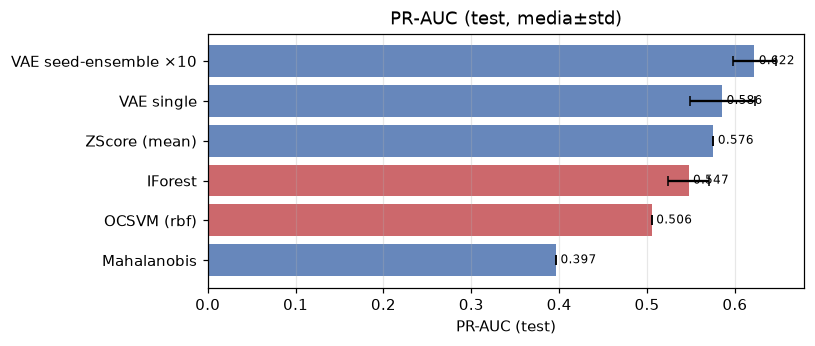

,pr_auc,roc_auc
VAE seed-ensemble ×10,0.622±0.025,0.765±0.023
VAE single,0.586±0.037,0.737±0.031
ZScore (mean),0.576±0.000,0.714±0.000
IForest,0.547±0.023,0.679±0.027
OCSVM (rbf),0.506±0.000,0.700±0.000
Mahalanobis,0.397±0.000,0.659±0.000


--- maíz ---


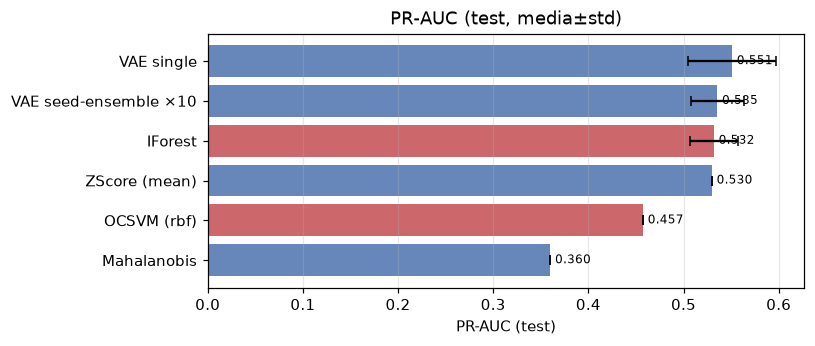

,pr_auc,roc_auc
VAE single,0.551±0.046,0.700±0.052
VAE seed-ensemble ×10,0.535±0.028,0.691±0.022
IForest,0.532±0.025,0.656±0.024
ZScore (mean),0.530±0.000,0.661±0.000
OCSVM (rbf),0.457±0.000,0.618±0.000
Mahalanobis,0.360±0.000,0.571±0.000


In [52]:
def comparar(dataset, single_c, filas_ens_c, nombre_cultivo):
    resumen_final = {
        "ZScore (mean)": [lab.metrics(ZScoreDetector(agg="mean").fit(dataset.X_train)
                                      .score_samples(dataset.X_test), dataset.y_test)],
        "Mahalanobis":   [lab.metrics(MahalanobisDetector(shrinkage=None).fit(dataset.X_train)
                                      .score_samples(dataset.X_test), dataset.y_test)],
        "IForest": [lab.metrics(IsolationForestDetector(n_estimators=200, max_features=0.3,
                    random_state=s).fit(dataset.X_train).score_samples(dataset.X_test), dataset.y_test)
                    for s in SEEDS],
        "OCSVM (rbf)": [lab.metrics(OneClassSVMDetector(kernel="rbf", nu=0.1)
                                    .fit(dataset.X_train).score_samples(dataset.X_test), dataset.y_test)],
        "VAE single": single_c,
        "VAE seed-ensemble ×10": filas_ens_c,
    }
    print(f"--- {nombre_cultivo} ---")
    lab.plot_leaderboard(lab.leaderboard(resumen_final)); plt.show()
    display(lab.tabla(resumen_final))

comparar(ds, single["soja"], filas_ens["soja"], "soja")
comparar(dsm, single["maiz"], filas_ens["maiz"], "maíz")

En **soja**, el seed-ensemble trae una mejora clara: baja la varianza entre corridas y sube el PR-AUC medio respecto del VAE de una sola semilla. En **maíz**, en cambio, el ensemble no mejora el PR-AUC medio (un VAE individual llega parecido o algo más alto), pero sí **reduce la variabilidad** entre semillas.

En ambos casos el ensemble cumple su rol principal: **estabilizar el score** (menor desvío entre corridas), aunque la ganancia en PR-AUC dependa del cultivo.

El desvío cae fuerte **y la media sube**: el promedio de scores independientes gana en
media y en el peor caso — en ambos cultivos.

## 4.3 · El modelo final, en ambos cultivos
Reusamos las réplicas base=42 de soja y maíz (ya entrenadas en 4.1), para los histogramas
de score.

> Ojo: el número **oficial** es la media±std de 4.1. Acá los scores son de **una réplica
> concreta** (base=42): su PR-AUC puntual cae *dentro* de ese ±std — no es un modelo
> distinto ni mejor.

In [55]:
sc_soja = ens_repr["soja"].score_samples(ds.X_test)    # réplica base=42 (ya entrenada en 4.1)
sc_maiz = ens_repr["maiz"].score_samples(dsm.X_test)    # ídem
print("soja (réplica 42):", {k: round(v,3) for k,v in lab.metrics(sc_soja, ds.y_test).items()})
print("maíz (réplica 42):", {k: round(v,3) for k,v in lab.metrics(sc_maiz, dsm.y_test).items()})

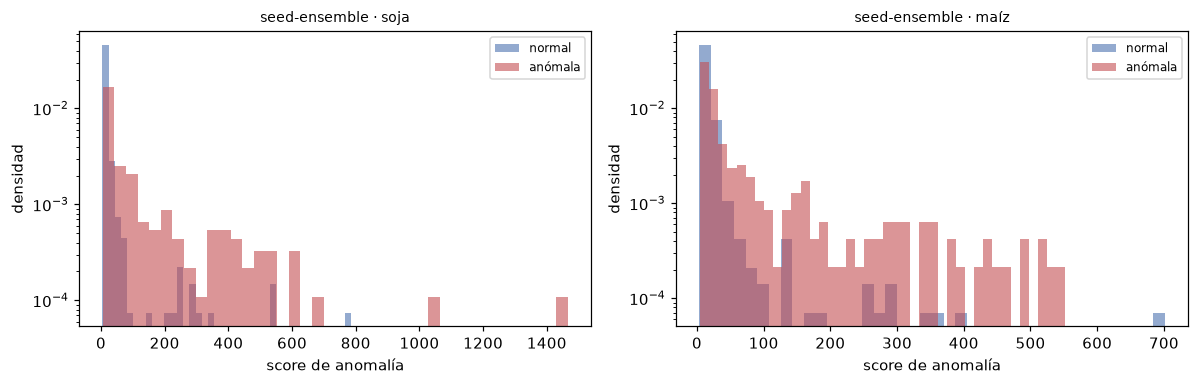

In [56]:
fig, axs = plt.subplots(1, 2, figsize=(11, 3.6))
lab.plot_scores(sc_soja, ds.y_test, ax=axs[0], titulo="seed-ensemble · soja")
lab.plot_scores(sc_maiz, dsm.y_test, ax=axs[1], titulo="seed-ensemble · maíz")
plt.tight_layout(); plt.show()

Se observa que la detección de campañas anómalas en **maíz** es más difícil: todos los métodos quedan muy parejos entre sí (poca separación entre normal y anómalo). En **soja**, en cambio, el seed-ensemble del VAE se impone al resto de los baselines, con varianza baja y el mayor PR-AUC medio.

## 4.4 · Sobre el latente del ensemble
El latente del ensemble **es el del miembro 0 (VAE con seed 42), idéntico al del nb 3** —
mismo modelo, misma semilla, mismos datos (cada cultivo con su propia config ganadora). Ya
lo analizamos ahí para ambos cultivos: IForest/OCSVM sobre ese latente **no** superan al
score directo, y su t-SNE muestra las anomalías mezcladas (sin cluster). No lo repetimos
acá para no duplicar el mismo gráfico.

**El seed-ensemble ×10 del VAE `recon_prob`** es el **modelo final**, con el menor desvío
entre semillas (ver la tabla de 4.1) — con `latent_dim=16` en soja y `latent_dim=24` en
maíz, cada uno el ganador de su propio grid (nb 3): la misma arquitectura no transfiere
óptimamente entre cultivos. Ni el latente + shallow lo supera. Corre sobre el panel
unificado (clima + NDVI + ERA5). En el nb 5 vemos por qué cuesta subir de acá (el techo) y en
el nb 6 chequeamos si las features agronómicas de dominio agregan algo más.